# Notebook 02 — In-Sample Model Comparison

This notebook fits all regime-switching models on the **pre-break** training sample
and evaluates their **in-sample** performance: how well do they recover the
true latent regimes and forecast ``y``?

**Models compared**
- Markov Switching Regression (MSM) — classical EM/Hamilton filter
- Hidden Markov Model (HMM) + per-regime Ridge
- Threshold Autoregression (TAR)
- ML Regime Switcher (KMeans + XGBoost)
- Mixture of Experts (EM soft-assignment)

**Metrics**
- Regime detection accuracy & Adjusted Rand Index
- Forecast RMSE and MAE
- Directional accuracy

In [2]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from simulation import MarkovSwitchingDGP
from simulation.lucas_shift import MILD_SHIFT, simulate_pre_post_break
from models import HMMRegimeModel, ThresholdModel, MLRegimeModel, MixtureOfExpertsModel, ARModel, ARMAModel, ModelAverageEnsemble
from models import MarkovSwitchingNeuralNetwork
from evaluation.metrics import (
    forecast_rmse, forecast_mae, directional_accuracy,
    regime_accuracy, adjusted_rand_regime, regime_conditional_rmse,
)
from evaluation.visualization import (
    plot_regime_comparison, plot_model_comparison_bar, save_figure
)

sns.set_theme(style='whitegrid', context='notebook')
warnings.filterwarnings('ignore')

print('Setup complete.')

Setup complete.


## 1. Load Data

In [3]:
data_dir = PROJECT_ROOT / 'data' / 'simulated'

if (data_dir / 'pre_break.parquet').exists():
    df_train = pd.read_parquet(data_dir / 'pre_break.parquet')
    print('Loaded pre-break data from parquet.')
else:
    dgp = MarkovSwitchingDGP(seed=42)
    df_train, _, _ = simulate_pre_post_break(dgp, MILD_SHIFT, n_pre=400, n_post=200)
    print('Simulated fresh pre-break data.')

print(f'Training set: {len(df_train)} observations')
print(df_train['regime_label'].value_counts())

Loaded pre-break data from parquet.
Training set: 481 observations
regime_label
recession    323
expansion    158
Name: count, dtype: int64


## 2. Fit All Models

In [4]:
models = {
    'AR(2) Baseline': ARModel(order=2, include_exog=True),
    'ARMA(2,1) Baseline': ARMAModel(p=2, q=1, trend='c'),
    'HMM': HMMRegimeModel(n_components=2, random_state=42),
    'Threshold (TAR)': ThresholdModel(),
    'ML Regime (XGB)': MLRegimeModel(n_regimes=2),
    'Mixture of Experts': MixtureOfExpertsModel(n_experts=2, n_iter=50, random_state=42),
    'MSNN': MarkovSwitchingNeuralNetwork(
        k_regimes=2,
        hidden_layer_sizes=(32, 16),
        n_iter=50,
        mlp_epochs=200,
        random_state=42,
    ),
}

# Add Markov Switching if statsmodels available
try:
    from models import MarkovSwitchingModel
    models['Markov Switching (MSM)'] = MarkovSwitchingModel(k_regimes=2, switching_variance=True)
    print('Markov Switching (MSM) added.')
except Exception as e:
    print(f'MSM not available: {e}')

print(f'Fitting {len(models)} models...')
for name, model in models.items():
    print(f'  Fitting {name}...')
    model.fit(df_train)
    print(f'    Done.')
# --- Model Average Ensemble ---
model_avg = ModelAverageEnsemble(models)
# Models already fitted above; ensemble just averages their predictions
pred_avg_train = model_avg.predict(df_train)
print(f'  Model Average computed from {len(models)} base models.')


Markov Switching (MSM) added.
Fitting 8 models...
  Fitting AR(2) Baseline...
    Done.
  Fitting ARMA(2,1) Baseline...
    Done.
  Fitting HMM...
    Done.
  Fitting Threshold (TAR)...
    Done.
  Fitting ML Regime (XGB)...
    Done.
  Fitting Mixture of Experts...
    Done.
  Fitting MSNN...
    Done.
  Fitting Markov Switching (MSM)...
    Done.
  Model Average computed from 8 base models.


## 3. Regime Recovery

In [5]:
true_regimes = df_train['regime'].to_numpy()
pred_regimes = {}

for name, model in models.items():
    try:
        pred_regimes[name] = model.predict_regimes(df_train)
    except Exception as e:
        print(f'{name} predict_regimes failed: {e}')

print('Regime detection performance:')
print(f'{"Model":<25} {"Accuracy":<12} {"ARI":<10}')
print('-' * 47)
for name, pred in pred_regimes.items():
    acc = regime_accuracy(true_regimes, pred)
    ari = adjusted_rand_regime(true_regimes, pred)
    print(f'{name:<25} {acc:<12.4f} {ari:<10.4f}')

Regime detection performance:
Model                     Accuracy     ARI       
-----------------------------------------------
AR(2) Baseline            0.6715       0.0000    
ARMA(2,1) Baseline        0.6715       0.0000    
HMM                       0.6403       0.0756    
Threshold (TAR)           0.5489       -0.0515   
ML Regime (XGB)           0.6424       0.0768    
Mixture of Experts        0.5759       -0.0216   
MSNN                      0.5094       -0.0019   
Markov Switching (MSM)    0.7526       0.2443    


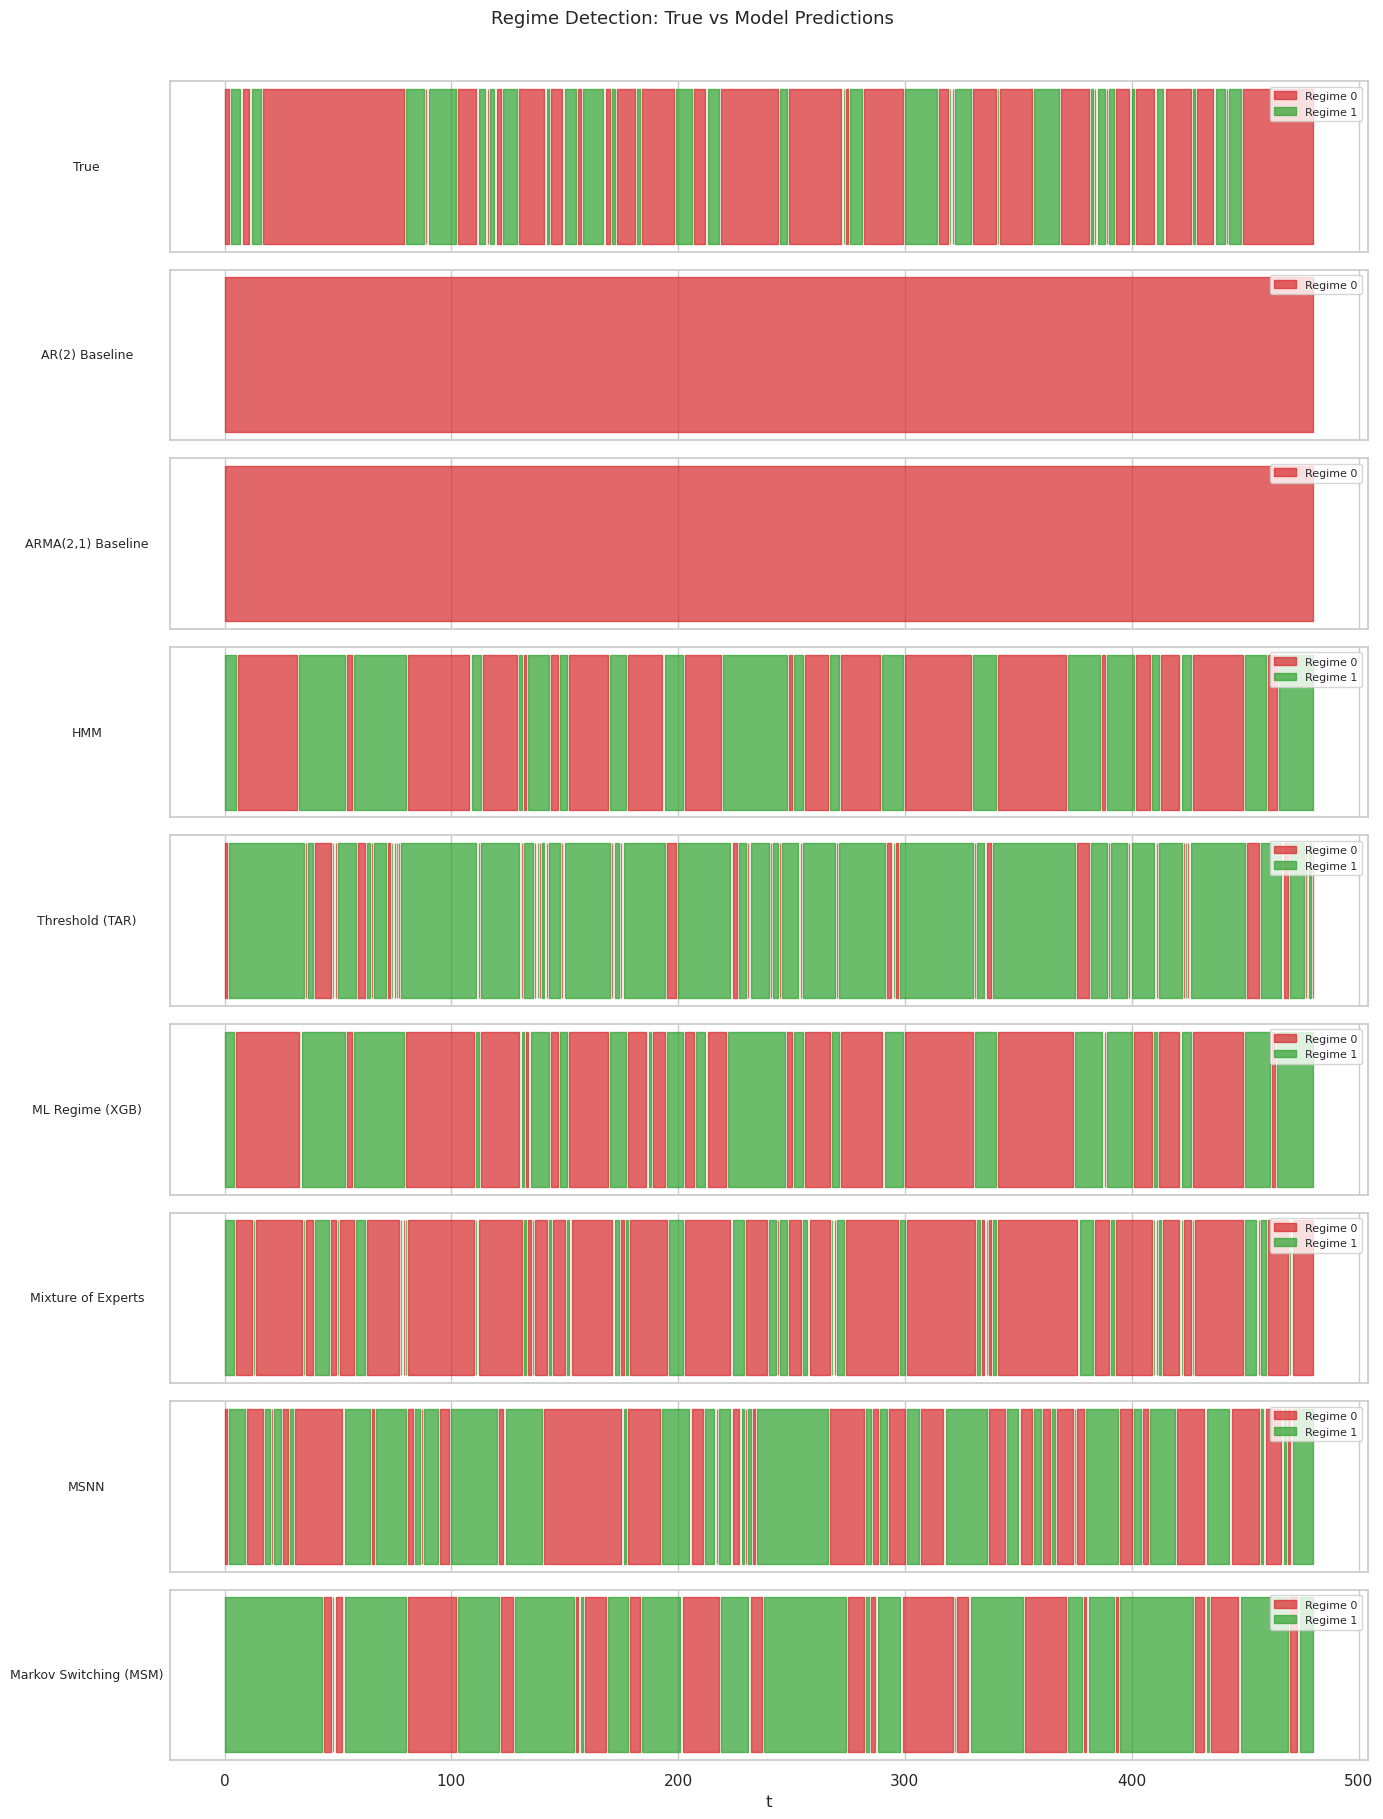

In [6]:
fig = plot_regime_comparison(true_regimes, pred_regimes)
save_figure(fig, '02_regime_comparison')
plt.show()

## 4. Forecast Accuracy

In [7]:
y_true = df_train['y'].to_numpy()
predictions = {}
results = []

for name, model in models.items():
    try:
        y_pred = model.predict(df_train)
        predictions[name] = y_pred
        results.append({
            'model': name,
            'rmse': forecast_rmse(y_true, y_pred),
            'mae': forecast_mae(y_true, y_pred),
            'dir_acc': directional_accuracy(y_true, y_pred),
            'regime_acc': regime_accuracy(true_regimes, pred_regimes.get(name, np.zeros_like(true_regimes))),
            'ari': adjusted_rand_regime(true_regimes, pred_regimes.get(name, np.zeros_like(true_regimes))),
        })
    except Exception as e:
        print(f'{name} predict failed: {e}')

results_df = pd.DataFrame(results)
print('In-sample forecast performance:')
print(results_df.to_string(index=False, float_format='{:.4f}'.format))

In-sample forecast performance:
                 model   rmse    mae  dir_acc  regime_acc     ari
        AR(2) Baseline 1.6340 1.2485   0.4708      0.6715  0.0000
    ARMA(2,1) Baseline 1.6739 1.2739   0.4729      0.6715  0.0000
                   HMM 1.6959 1.2933   0.5062      0.6403  0.0756
       Threshold (TAR) 1.5370 1.1846   0.5354      0.5489 -0.0515
       ML Regime (XGB) 0.3957 0.2969   0.9042      0.6424  0.0768
    Mixture of Experts 1.3393 1.0242   0.5979      0.5759 -0.0216
                  MSNN 0.6128 0.3406   0.8771      0.5094 -0.0019
Markov Switching (MSM) 1.6732 1.2725   0.4437      0.7526  0.2443


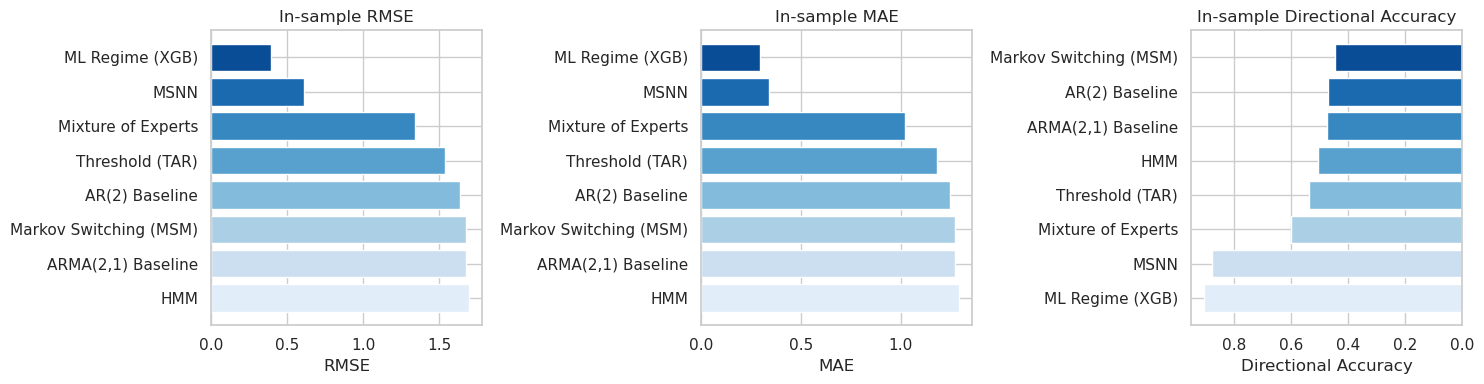

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric, ylabel in zip(axes, ['rmse', 'mae', 'dir_acc'],
                               ['RMSE', 'MAE', 'Directional Accuracy']):
    df_sorted = results_df.sort_values(metric)
    colors = sns.color_palette('Blues_r', len(df_sorted))
    ax.barh(df_sorted['model'], df_sorted[metric], color=colors)
    ax.set_xlabel(ylabel)
    ax.set_title(f'In-sample {ylabel}')
    if metric == 'dir_acc':
        ax.invert_xaxis()
        ax.invert_yaxis()
    else:
        ax.invert_yaxis()

plt.tight_layout()
save_figure(fig, '02_insample_performance')
plt.show()

## 5. Per-Regime RMSE Breakdown

In [9]:
print('RMSE broken down by true regime:')
print(f'{"Model":<25} {"Recession RMSE":<18} {"Expansion RMSE":<18}')
print('-' * 61)

for name, y_pred in predictions.items():
    cond_rmse = regime_conditional_rmse(y_true, y_pred, true_regimes)
    rec = cond_rmse.get(0, float('nan'))
    exp = cond_rmse.get(1, float('nan'))
    print(f'{name:<25} {rec:<18.4f} {exp:<18.4f}')

RMSE broken down by true regime:
Model                     Recession RMSE     Expansion RMSE    
-------------------------------------------------------------
AR(2) Baseline            1.8639             1.0130            
ARMA(2,1) Baseline        1.8753             1.1578            
HMM                       1.8963             1.1850            
Threshold (TAR)           1.7214             1.0648            
ML Regime (XGB)           0.4253             0.3270            
Mixture of Experts        1.4548             1.0650            
MSNN                      0.6877             0.4199            
Markov Switching (MSM)    1.9007             1.0667            


## 6. Predicted vs True: Time Series

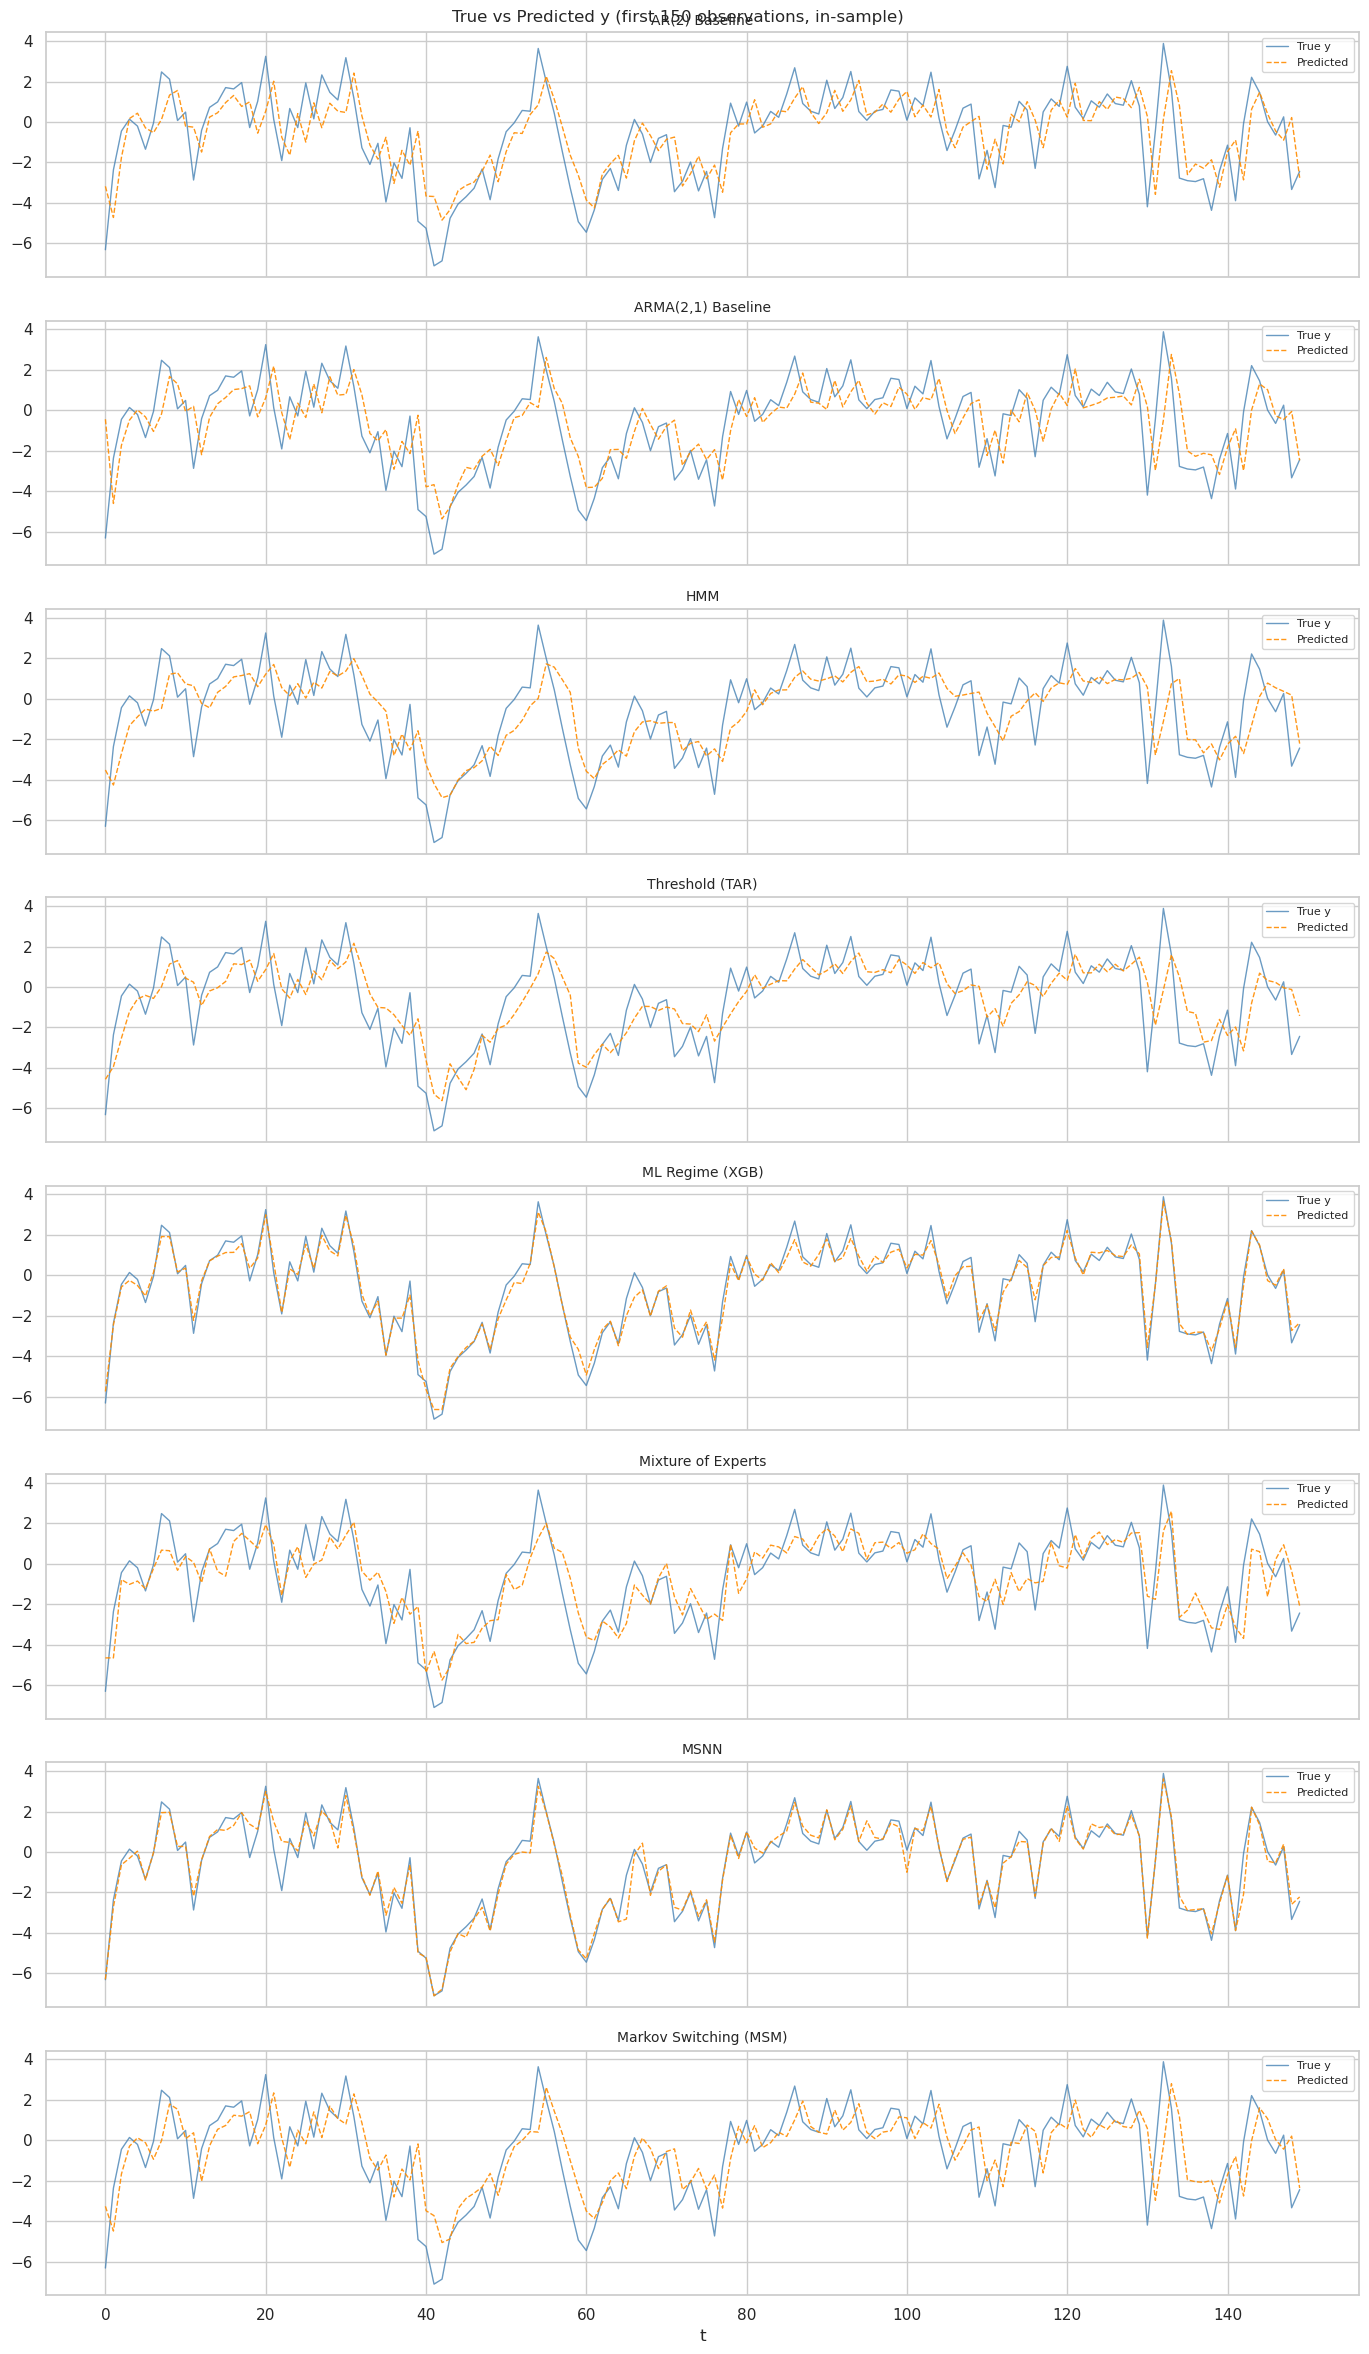

In [10]:
n_plot = min(150, len(df_train))
t = np.arange(n_plot)

fig, axes = plt.subplots(len(predictions), 1, figsize=(14, 3 * len(predictions)), sharex=True)
if len(predictions) == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.plot(t, y_true[:n_plot], color='steelblue', lw=1, label='True y', alpha=0.8)
    ax.plot(t, y_pred[:n_plot], color='darkorange', lw=1, ls='--', label='Predicted', alpha=0.9)
    ax.set_title(name, fontsize=10)
    ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel('t')
fig.suptitle('True vs Predicted y (first 150 observations, in-sample)', fontsize=12)
plt.tight_layout()
save_figure(fig, '02_predictions_vs_true')
plt.show()

## 7. Save Results

In [11]:
results_df.to_csv(data_dir / 'insample_results.csv', index=False)
print('In-sample results saved.')

In-sample results saved.
